<a href="https://colab.research.google.com/github/BarshaPanthi7/Danphe_task_Barsha/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kaggle API configuration

In [ ]:
from google.colab import files
files.upload()

In [2]:
import os, shutil
os.makedirs("/root/.config/kaggle", exist_ok=True)
shutil.move("/content/kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [3]:
!pip install -q --upgrade kaggle
!kaggle --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 3.9 MB/s eta 0:00:00
Kaggle CLI 2.2.4


ptb xl dataset metadata

In [4]:
!kaggle datasets files -d physionet/ptbxl-electrocardiography-database --page-size 200

Next Page Token = CfDJ8GNxPX3qpaJEpxfoBSRBZPd27nMvwdnsWo93BxtPqcFsjxE18SibYk1FdXqwU3ZWLK9fyHxMnA0gEQMPjiz_K1R2l-5YG5iwcjhLKTXnaqbccTaJwc-UaG_wTCHRyBEjfgYRyJXhDw
name                size  creationDate                
----------------  ------  --------------------------  
WFDB/HR00001.hea     666  2020-06-15 08:12:13.856000  
WFDB/HR00001.mat  120024  2020-06-15 08:12:13.794000  
WFDB/HR00002.hea     664  2020-06-15 08:12:13.787000  
WFDB/HR00002.mat  120024  2020-06-15 08:12:13.817000  
WFDB/HR00003.hea     661  2020-06-15 08:12:13.827000  
WFDB/HR00003.mat  120024  2020-06-15 08:12:13.785000  
WFDB/HR00004.hea     663  2020-06-15 08:12:13.759000  
WFDB/HR00004.mat  120024  2020-06-15 08:12:13.762000  
WFDB/HR00005.hea     658  2020-06-15 08:12:13.806000  
WFDB/HR00005.mat  120024  2020-06-15 08:12:13.827000  
WFDB/HR00006.hea     659  2020-06-15 08:12:13.771000  
WFDB/HR00006.mat  120024  2020-06-15 08:12:13.837000  
WFDB/HR00007.hea     660  2020-06-15 08:12:13.782000  
WFDB/HR00007.m

## PTB-XL Dataset

Downloading the PTB-XL dataset via Kaggle's Python API.

In [5]:
import kagglehub

# downloading the dataset
path = kagglehub.dataset_download('physionet/ptbxl-electrocardiography-database')

100%|██████████| 1.35G/1.35G [01:00<00:00, 23.9MB/s]

Extracting files...


### Dataset structure

This dataset stores ECG records in WFDB format (WaveForm DataBase) rather than a single CSV.
Each record has two files:
- `.hea` - header file with metadata (age, sex, diagnosis code, sampling rate)
- `.mat` - the raw ECG signal data

In [6]:
print("Contents of path:", os.listdir(path))

Contents of path: ['WFDB']


In [7]:
import os

wfdb_path = os.path.join(path, 'WFDB')
files = os.listdir(wfdb_path)
hea_files = [f for f in files if f.endswith('.hea')]

print("Number of header files:", len(hea_files))

Number of header files: 21837


In [8]:
# previewing one header file to see what metadata is stored inside
with open(os.path.join(wfdb_path, hea_files[0])) as f:
    print(f.read())

HR00194 12 500 5000 04-Jun-2020 15:11:55
HR00194.mat 16+24 200/mV 16 0 -20 27566 0 I
HR00194.mat 16+24 200/mV 16 0 -10 -14463 0 II
HR00194.mat 16+24 200/mV 16 0 10 23485 0 III
HR00194.mat 16+24 200/mV 16 0 15 25708 0 aVR
HR00194.mat 16+24 200/mV 16 0 -15 -30307 0 aVL
HR00194.mat 16+24 200/mV 16 0 0 4360 0 aVF
HR00194.mat 16+24 200/mV 16 0 75 19472 0 V1
HR00194.mat 16+24 200/mV 16 0 10 18526 0 V2
HR00194.mat 16+24 200/mV 16 0 -5 14271 0 V3
HR00194.mat 16+24 200/mV 16 0 55 6220 0 V4
HR00194.mat 16+24 200/mV 16 0 50 -7812 0 V5
HR00194.mat 16+24 200/mV 16 0 335 -26065 0 V6
#Age: 37
#Sex: Male
#Dx: 164934002,426783006
#Rx: Unknown
#Hx: Unknown
#Sx: Unknown



###  Parsing metadata from header files

Each `.hea` file contains per-record metadata (age, sex, diagnosis code, sampling rate) embedded as plain text. Since this dataset does not include a separate metadata CSV, metadata is extracted directly from the header files.

In [9]:
import re
import pandas as pd

records = []

for fname in hea_files:
    filepath = os.path.join(wfdb_path, fname)
    with open(filepath) as f:
        content = f.read()

    record_id = fname.replace('.hea', '')

    # puling out age, sex, and diagnosis code from the header text
    age_match = re.search(r'#Age:\s*(\S+)', content)
    sex_match = re.search(r'#Sex:\s*(\S+)', content)
    dx_match = re.search(r'#Dx:\s*(\S+)', content)

    # first line of the header holds sampling rate and sample count
    first_line = content.splitlines()[0].split()
    fs = int(first_line[2])
    n_samples = int(first_line[3])

    records.append({
        'record_id': record_id,
        'age': age_match.group(1) if age_match else None,
        'sex': sex_match.group(1) if sex_match else None,
        'dx_code': dx_match.group(1) if dx_match else None,
        'sampling_rate': fs,
        'n_samples': n_samples
    })

ptbxl_df = pd.DataFrame(records)
print("Shape:", ptbxl_df.shape)
ptbxl_df.head()

Shape: (21837, 6)


,record_id,age,sex,dx_code,sampling_rate,n_samples
0,HR00194,37,Male,"164934002,426783006",500,5000
1,HR14648,62,Female,"164861001,164873001,426783006",500,5000
2,HR18162,66,Female,"164861001,164873001,164951009,426783006",500,5000
3,HR08529,77,Female,"164934002,426783006",500,5000
4,HR17901,52,Male,"39732003,426783006",500,5000


last 10 rows

In [10]:
ptbxl_df.tail(10)

,record_id,age,sex,dx_code,sampling_rate,n_samples
21827,HR16807,89,Female,"164861001,164865005,164934002,426783006,429622005",500,5000
21828,HR08199,31,Male,426783006,500,5000
21829,HR09353,18,Female,426783006,500,5000
21830,HR12088,70,Female,426783006,500,5000
21831,HR17796,77,Female,"164931005,426783006",500,5000
21832,HR18400,51,Male,"164873001,426783006",500,5000
21833,HR14664,77,Female,426783006,500,5000
21834,HR15065,69,Male,"39732003,426783006",500,5000
21835,HR01724,40,Female,426783006,500,5000
21836,HR15732,47,Male,426783006,500,5000


missing value check

In [11]:
ptbxl_df.isnull().sum()

,0
record_id,0
age,0
sex,0
dx_code,0
sampling_rate,0
n_samples,0


age distribution

In [12]:
# converting age to numbers (it was read in as text)
ptbxl_df['age'] = pd.to_numeric(ptbxl_df['age'], errors='coerce')
ptbxl_df['age'].describe()

,age
count,21748.000000
mean,59.836307
std,16.953125
min,2.000000
25%,50.000000
50%,62.000000
75%,72.000000
max,95.000000


**Finding:** the dataset is skewed toward older/middle-aged adults
(median age 62), consistent with a cardiology dataset.

 ECG
abnormalities become more common with age. The youngest patient (age 2)
is worth a quick sanity check to confirm it's a genuine case rather
than a data entry issue.

## Investigating missing age values

The missing-value check above showed 0 missing ages, but converting
the column to numbers revealed 89 missing values. This is because the
header files store missing age as the literal text "NaN" rather than
leaving the field blank, pandas only treats this as a true missing
value after the column is converted to a numeric type.

In [13]:
invalid_ages = ptbxl_df[ptbxl_df['age'].isnull()]
print("Number of records with invalid/missing age:", len(invalid_ages))
invalid_ages.head(10)

Number of records with invalid/missing age: 89


,record_id,age,sex,dx_code,sampling_rate,n_samples
120,HR14327,NaN,Female,"164865005,164934002,426783006",500,5000
146,HR06892,NaN,Male,"164861001,164865005,164873001,164889003,426761...",500,5000
652,HR06027,NaN,Male,"164884008,39732003,426783006,713426002",500,5000
956,HR00256,NaN,Female,"164884008,164909002,426783006",500,5000
1349,HR14535,NaN,Female,"164861001,164865005,164873001,164889003,429622005",500,5000
1495,HR01597,NaN,Female,426783006,500,5000
1733,HR10054,NaN,Female,"164861001,164889003,428750005,429622005,59931005",500,5000
1741,HR14331,NaN,Female,"164861001,164865005,164947007,426783006,428750005",500,5000
1752,HR06017,NaN,Female,"164873001,164934002,426783006,429622005",500,5000
2551,HR08620,NaN,Female,"164909002,27885002",500,5000


In [14]:
# checking the raw header text for a few of these records
for record_id in invalid_ages['record_id'].head(5):
    filepath = os.path.join(wfdb_path, record_id + '.hea')
    with open(filepath) as f:
        content = f.read()
    age_line = [line for line in content.splitlines() if '#Age' in line]
    print(record_id, '->', age_line)

HR14327 -> ['#Age: NaN']
HR06892 -> ['#Age: NaN']
HR06027 -> ['#Age: NaN']
HR00256 -> ['#Age: NaN']
HR14535 -> ['#Age: NaN']


**Finding:** 89 of 21,837 records (0.4%) have age explicitly recorded
as "NaN" in the original header files, meaning age was not captured
for these recordings. These records are excluded from age-based
statistics but keep their valid sex, diagnosis, and signal data.

Sex distribution

In [15]:
ptbxl_df['sex'].value_counts()

,count
sex,
Male,11379
Female,10458


### Finding

The dataset is roughly balanced by sex: 11,379 male records (52.1%) and 10,458 female records (47.9%). No significant class imbalance is present.

sex distribution visualization

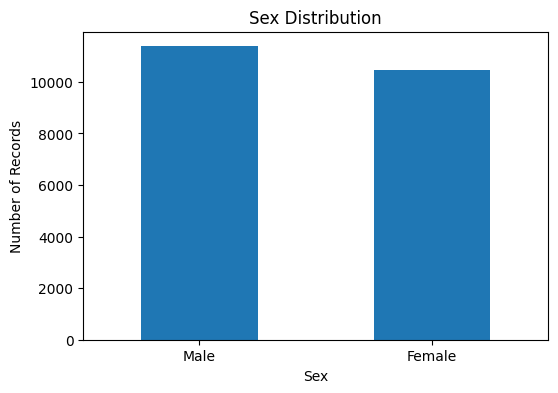

In [22]:
plt.figure(figsize=(6, 4))

ptbxl_df['sex'].value_counts().plot(kind='bar')

plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

checking duplicate records

In [16]:
# Checking for duplicate record IDs
print("Duplicate record IDs:", ptbxl_df['record_id'].duplicated().sum())

# Checking for completely duplicated rows
print("Duplicate rows:", ptbxl_df.duplicated().sum())

Duplicate record IDs: 0
Duplicate rows: 0


**Finding**

The dataset contains unique ECG record IDs, and there are no completely duplicated records. This indicates that each row represents a separate ECG recording.

Sampling rate distribution

The sampling rate shows how many ECG measurements are recorded per second. Most PTB-XL recordings use the same standard sampling rate, while a smaller number may use another rate.

In [17]:
# Check the different sampling rates used in the dataset
ptbxl_df['sampling_rate'].value_counts()

,count
sampling_rate,
500,21837


visualizing sampling rate

having a consistent sampling rate makes ECG signal analysis easier.

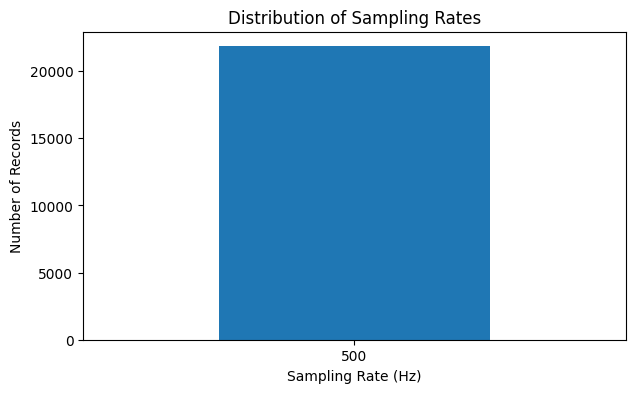

In [18]:
import matplotlib.pyplot as plt

# Counting the number of records for each sampling rate
sampling_counts = ptbxl_df['sampling_rate'].value_counts()

plt.figure(figsize=(7, 4))
sampling_counts.plot(kind='bar')

plt.title('Distribution of Sampling Rates')
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

age distribution visualization

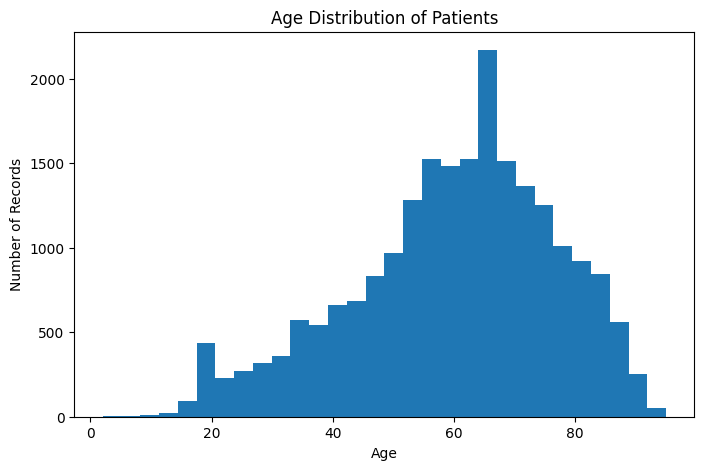

In [19]:
plt.figure(figsize=(8, 5))

# Histogram of patient ages
plt.hist(ptbxl_df['age'].dropna(), bins=30)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Records')
plt.show()

age group distribution

In [20]:
# Creating age groups
bins = [0, 18, 30, 45, 60, 75, 100]
labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76+']

ptbxl_df['age_group'] = pd.cut(
    ptbxl_df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counting records in each age group
ptbxl_df['age_group'].value_counts().sort_index()

,count
age_group,
0-18,301
19-30,1198
31-45,2693
46-60,6094
61-75,7422
76+,4040


**Findings**

The age-group analysis shows that most ECG recordings belong to older age groups, particularly patients above 45 years. Younger patients represent a smaller proportion of the dataset.

age group visualization

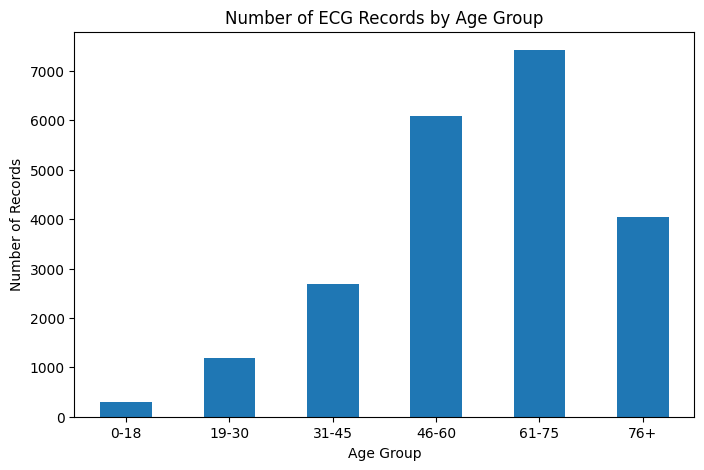

In [21]:
plt.figure(figsize=(8, 5))

ptbxl_df['age_group'].value_counts().sort_index().plot(kind='bar')

plt.title('Number of ECG Records by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

Diagnosis code distribution
dx_code

In [23]:
# Number of unique diagnosis codes
print("Number of unique diagnosis codes:", ptbxl_df['dx_code'].nunique())

# Displaying the most common diagnosis codes
ptbxl_df['dx_code'].value_counts().head(15)

Number of unique diagnosis codes: 3417


,count
dx_code,
426783006,6432
"39732003,426783006",755
"164934002,426783006",712
"164865005,164951009,426783006",532
"164865005,164951009,39732003,426783006",498
"164873001,426783006",344
"426783006,427393009",304
"426783006,713426002",303
"164865005,426783006",288


how many ECG records contain that individual diagnosis code

In [30]:
# Removing missing diagnosis values
dx_data = ptbxl_df['dx_code'].dropna()

# Splitting multiple diagnosis codes and count each individual code
individual_dx = dx_data.str.split(',').explode()

# Counting individual diagnosis codes
individual_dx.value_counts().head(15)

,count
dx_code,
426783006,18092
164865005,5261
39732003,5146
164951009,3389
164873001,2359
164934002,2345
164861001,2175
445118002,1626
164889003,1514


actual number of individual diagnosis codes

In [31]:
# Number of unique individual diagnosis codes
print("Number of unique individual diagnosis codes:",
      individual_dx.nunique())

Number of unique individual diagnosis codes: 50


top 10 diagnosis visualization

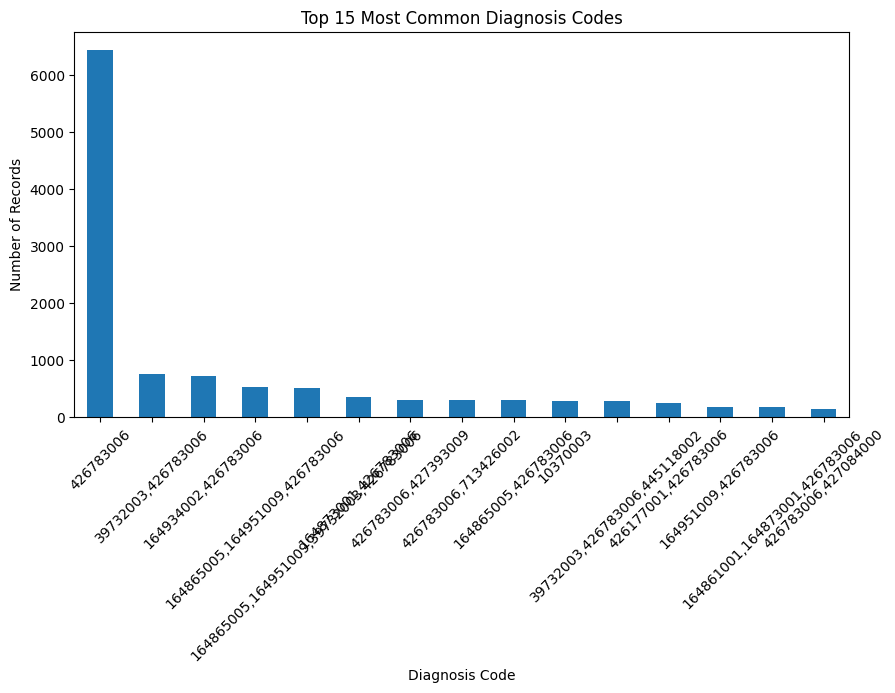

In [24]:
# Selecting the 15 most common diagnosis codes
top_dx = ptbxl_df['dx_code'].value_counts().head(15)

plt.figure(figsize=(10, 5))

top_dx.plot(kind='bar')

plt.title('Top 15 Most Common Diagnosis Codes')
plt.xlabel('Diagnosis Code')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)

plt.show()

number of samples per ecg record

In [25]:
# Basic statistics of the number of samples in each ECG recording
ptbxl_df['n_samples'].describe()

,n_samples
count,21837.0
mean,5000.0
std,0.0
min,5000.0
25%,5000.0
50%,5000.0
75%,5000.0
max,5000.0


visualizing ecg signal length

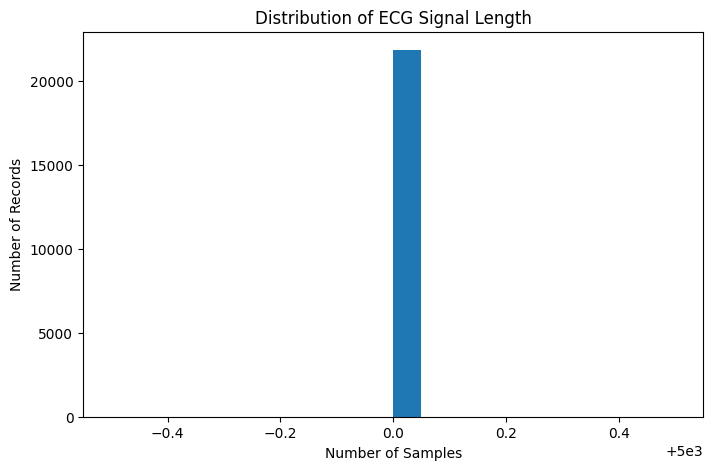

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(ptbxl_df['n_samples'], bins=20)

plt.title('Distribution of ECG Signal Length')
plt.xlabel('Number of Samples')
plt.ylabel('Number of Records')

plt.show()

Checking relationship between age and signal length

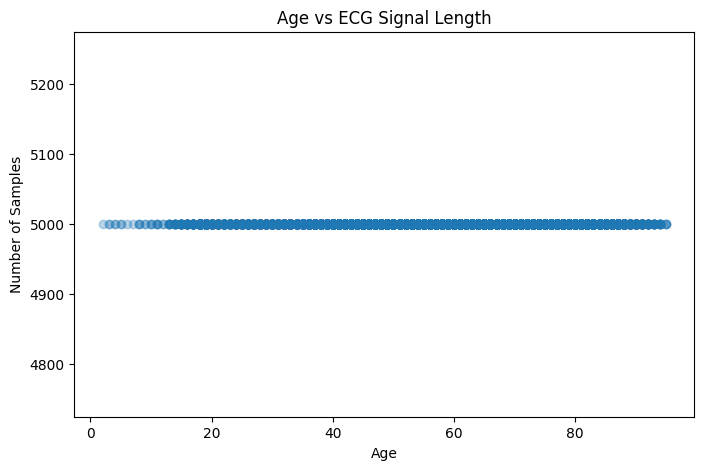

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    ptbxl_df['age'],
    ptbxl_df['n_samples'],
    alpha=0.3
)

plt.title('Age vs ECG Signal Length')
plt.xlabel('Age')
plt.ylabel('Number of Samples')

plt.show()

In [32]:
ptbxl_df['n_samples'].value_counts()

,count
n_samples,
5000,21837


Basic correlation analysis

In [28]:
# Selecting numerical columns
numeric_cols = ['age', 'sampling_rate', 'n_samples']

# Calculating correlation
ptbxl_df[numeric_cols].corr()

,age,sampling_rate,n_samples
age,1.0,NaN,NaN
sampling_rate,NaN,NaN,NaN
n_samples,NaN,NaN,NaN
